In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)
print("Libraries Imported Successfully")

TensorFlow Version: 2.20.0
Libraries Imported Successfully


In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


In [3]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape images for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Data Preprocessing Completed")

Data Preprocessing Completed


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the CNN model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - accuracy: 0.9431 - loss: 0.1892 - val_accuracy: 0.9827 - val_loss: 0.0630
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9814 - loss: 0.0591 - val_accuracy: 0.9875 - val_loss: 0.0468
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9866 - loss: 0.0425 - val_accuracy: 0.9863 - val_loss: 0.0454
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.9895 - loss: 0.0330 - val_accuracy: 0.9877 - val_loss: 0.0468
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.9924 - loss: 0.0255 - val_accuracy: 0.9882 - val_loss: 0.0441


In [6]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy * 100, "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9898 - loss: 0.0327
Test Loss: 0.03267979249358177
Test Accuracy: 98.9799976348877 %


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


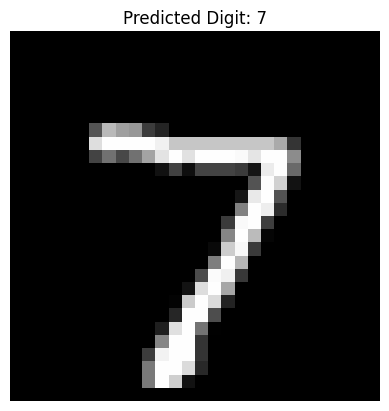

Actual Digit: 7


In [7]:
# Predict a test image
predictions = model.predict(x_test[:1])

predicted_digit = np.argmax(predictions[0])

plt.imshow(x_test[0].reshape(28, 28), cmap="gray")
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis("off")
plt.show()

print("Actual Digit:", y_test[0])

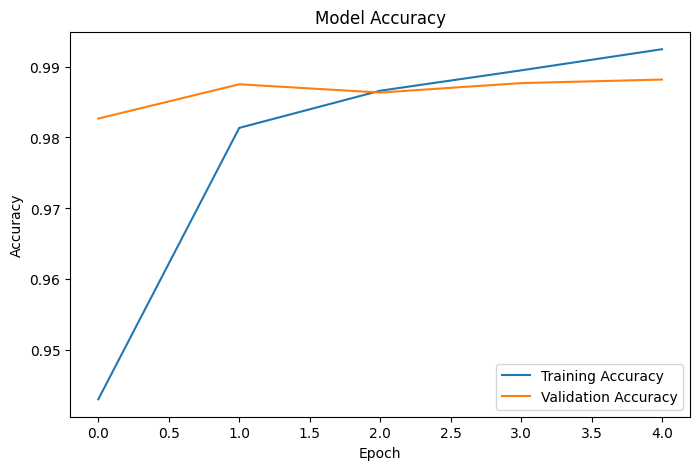

In [8]:
# Plot Training and Validation Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Experiment No. 10**

**Experiment Name: Character, Digit, or Face Classification using Convolutional Neural Networks (CNNs)**

Aim: To implement a Convolutional Neural Network (CNN) for handwritten digit classification using the MNIST dataset.

Theory: CNN is a deep learning technique used for image classification. It uses convolutional and pooling layers to extract important features from images and fully connected layers to classify them into different categories.

Dataset: MNIST Handwritten Digit Dataset (digits 0–9).

Procedure:

Import the required libraries.

Load the MNIST dataset.

Normalize and preprocess the images.

Build a CNN model using convolutional and pooling layers.

Train the model using the training dataset.

Evaluate the model using the test dataset.

Predict handwritten digits and visualize the results.

Result: The CNN model was successfully implemented and trained on the MNIST dataset. The model predicted handwritten digits and its performance was evaluated using test accuracy and loss.